<a id='II-8'></a>
## **8. ARIMA Forecasting**

### 8.1 Train/Test Split

In [17]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

# ── Load data ─────────────────────────────────────────────────────────────────
with open('outputs/processed/cleaned_data.pkl', 'rb') as f:
    data = pickle.load(f)

monthly_sales = data['monthly_sales']
OS_daily      = data['OS_daily']

print(" Ready!")
print(f"   monthly_sales: {len(monthly_sales)} rows")

 Ready!
   monthly_sales: 48 rows


Training set: 36 months (Jan 2014 – Dec 2016)
Test set:     12 months (Jan 2017 – Dec 2017)


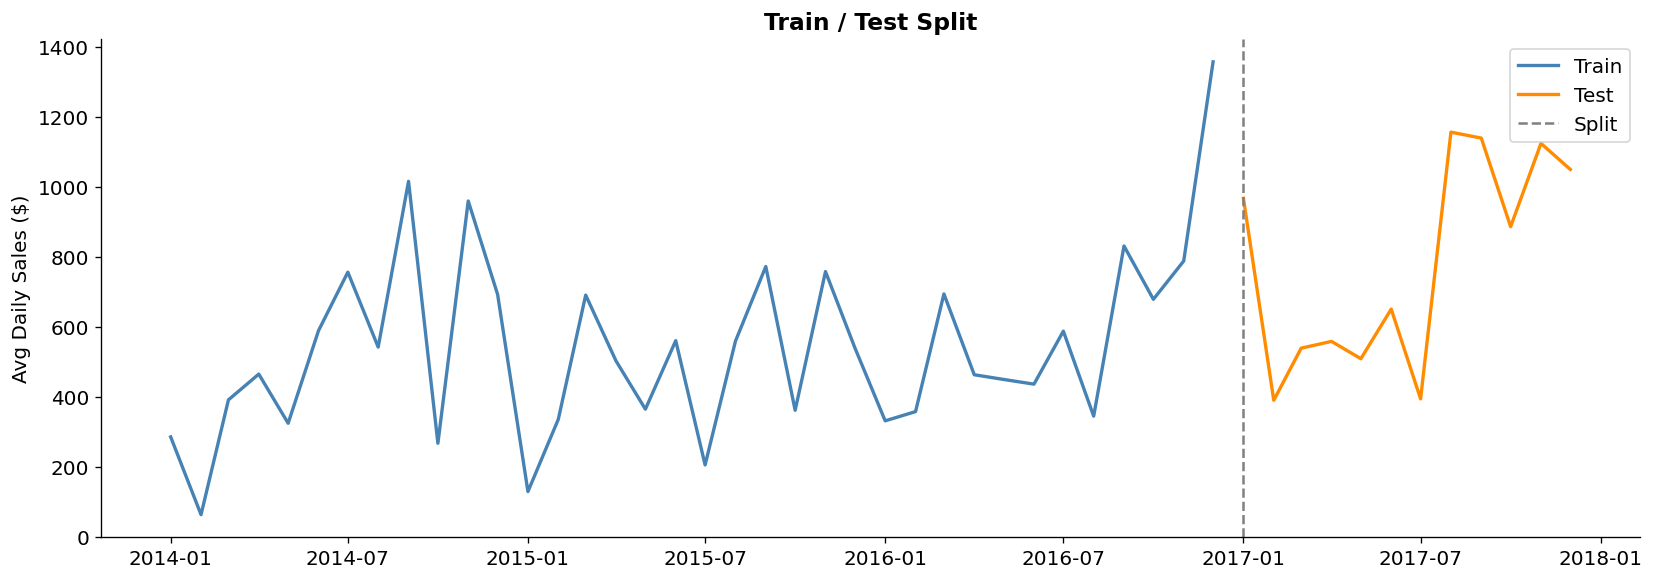

In [18]:
# We use the last 12 months as the test set (1 full year)
n_test = 12
train = monthly_sales[:-n_test]
test  = monthly_sales[-n_test:]

print(f"Training set: {len(train)} months ({train.index[0].strftime('%b %Y')} – {train.index[-1].strftime('%b %Y')})")
print(f"Test set:     {len(test)} months ({test.index[0].strftime('%b %Y')} – {test.index[-1].strftime('%b %Y')})")

# Visualize split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train, label='Train', color='steelblue', linewidth=2)
ax.plot(test,  label='Test',  color='darkorange', linewidth=2)
ax.axvline(test.index[0], color='gray', linestyle='--', label='Split')
ax.set_title('Train / Test Split', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Daily Sales ($)')
ax.legend()
plt.tight_layout()
plt.show()

### 8.2 Auto-ARIMA: Finding Optimal (p, d, q)

In [19]:
print("Running auto_arima to find best (p, d, q) for non-seasonal ARIMA...")
print("(This may take a moment)\n")

arima_model_search = auto_arima(
    train,
    test='adf',           # Use ADF test to determine d
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,               # Let auto_arima determine d
    seasonal=False,       # Non-seasonal ARIMA
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(f"\n Best ARIMA order: {arima_model_search.order}")
print(f"   AIC: {arima_model_search.aic():.2f}")

Running auto_arima to find best (p, d, q) for non-seasonal ARIMA...
(This may take a moment)

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=531.710, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=514.869, Time=0.04 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=529.767, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=496.431, Time=2.18 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=491.352, Time=0.24 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=488.738, Time=0.46 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(3,2,1)(0,0,0)[0]             : AIC=486.840, Time=0.35 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=inf, Time=0.63 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=489.453, Time=0.06 sec
 ARIMA(3,2,2)(0,0,0)[0]             : 

### 8.3 Fit ARIMA Model

In [20]:
best_order = arima_model_search.order

arima_model = ARIMA(train, order=best_order)
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -238.420
Date:                Wed, 27 May 2026   AIC                            486.840
Time:                        16:32:15   BIC                            494.472
Sample:                    01-01-2014   HQIC                           489.443
                         - 12-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8836      0.318     -2.777      0.005      -1.507      -0.260
ar.L2         -0.5659      0.415     -1.364      0.173      -1.379       0.247
ar.L3         -0.0465      0.301     -0.154      0.8

### 8.4 ARIMA Diagnostics

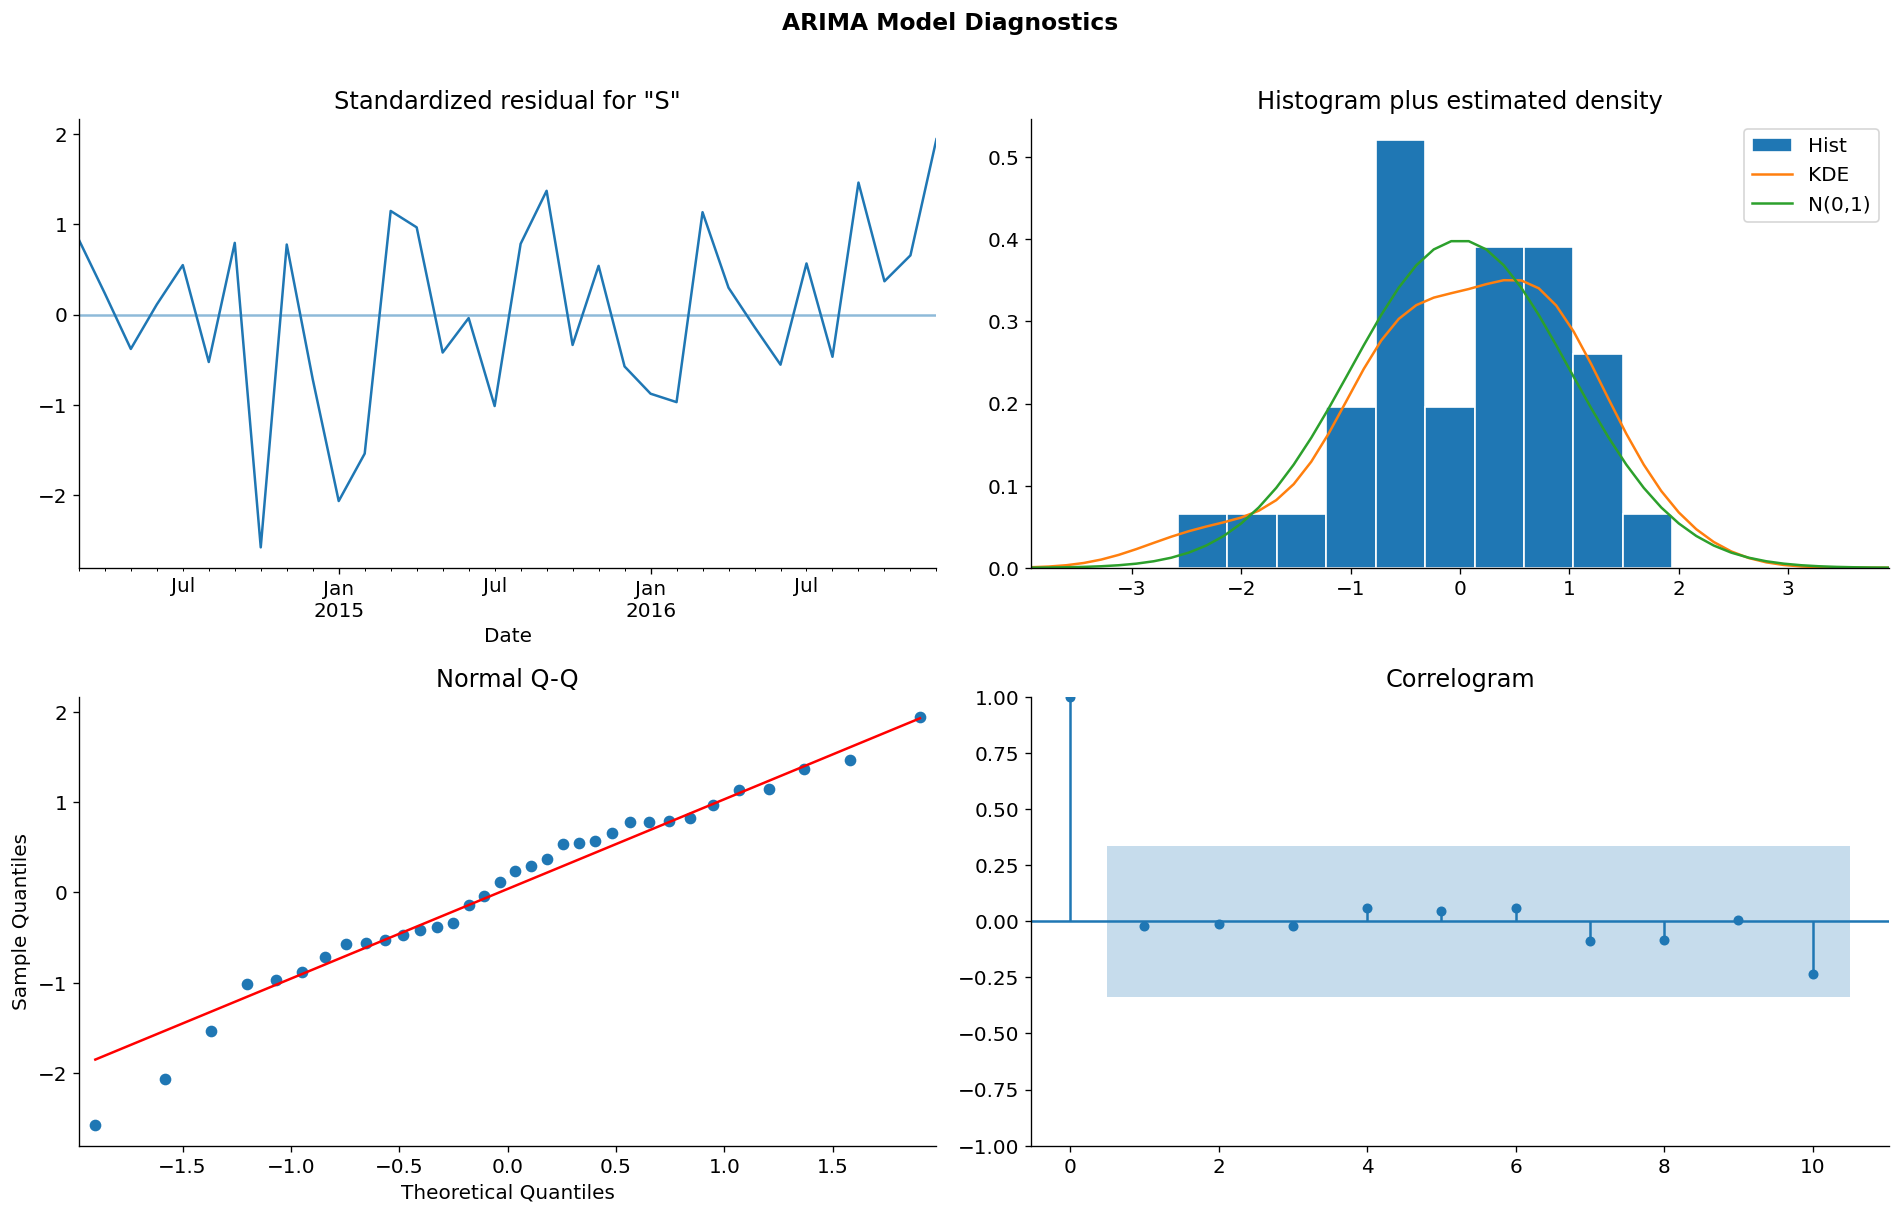

📊 Diagnostic Interpretation:
  • Standardized residuals: Should look like white noise
  • Histogram + KDE: Should approximate normal distribution
  • Q-Q plot: Points along diagonal → normally distributed residuals
  • Correlogram (ACF): No significant autocorrelation in residuals → good fit


In [21]:
# Plot residuals diagnostics
arima_result.plot_diagnostics(figsize=(16, 10))
plt.suptitle('ARIMA Model Diagnostics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("📊 Diagnostic Interpretation:")
print("  • Standardized residuals: Should look like white noise")
print("  • Histogram + KDE: Should approximate normal distribution")
print("  • Q-Q plot: Points along diagonal → normally distributed residuals")
print("  • Correlogram (ACF): No significant autocorrelation in residuals → good fit")

### 8.5 ARIMA Prediction & Evaluation

In [22]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

In [23]:
def evaluate_forecast(actual, predicted, model_name='Model'):
    """Compute and display forecast evaluation metrics."""
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    metrics = pd.DataFrame({
        'Metric': ['MAPE (%)', 'MAE ($)', 'RMSE ($)'],
        'Value':  [f'{mape:.2f}%', f'{mae:.2f}', f'{rmse:.2f}']
    })
    print(f"\n{'='*40}")
    print(f"  {model_name} — Evaluation Metrics")
    print(f"{'='*40}")
    print(metrics.to_string(index=False))
    
    return {'mape': mape, 'mae': mae, 'rmse': rmse}

# Predict on test set
arima_pred = arima_result.forecast(steps=n_test)
arima_pred.index = test.index

arima_metrics = evaluate_forecast(test, arima_pred, 'ARIMA')


  ARIMA — Evaluation Metrics
  Metric   Value
MAPE (%) 125.48%
 MAE ($)  783.18
RMSE ($)  831.16


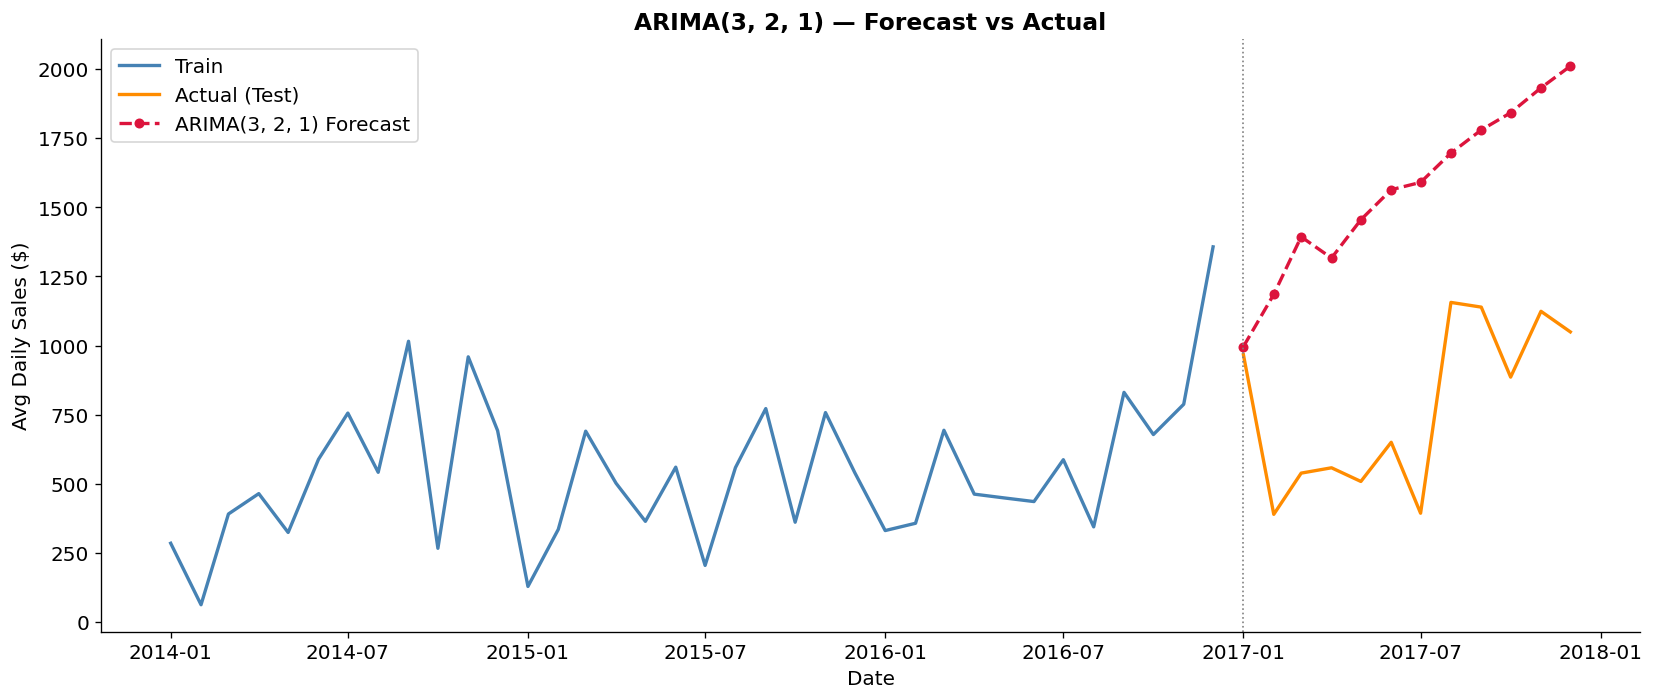

⚠️  ARIMA cannot capture seasonal patterns.
   Notice the forecast misses the year-end sales peak.
   Solution: Use SARIMAX with seasonal parameters.


In [24]:
# Plot ARIMA forecast vs actual
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train, label='Train', color='steelblue', linewidth=2)
ax.plot(test,  label='Actual (Test)', color='darkorange', linewidth=2)
ax.plot(arima_pred, label=f'ARIMA{best_order} Forecast',
        color='crimson', linewidth=2, linestyle='--', marker='o', markersize=5)
ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1)
ax.set_title(f'ARIMA{best_order} — Forecast vs Actual', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Daily Sales ($)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

print("⚠️  ARIMA cannot capture seasonal patterns.")
print("   Notice the forecast misses the year-end sales peak.")
print("   Solution: Use SARIMAX with seasonal parameters.")

<a id='II-9'></a>
## **9. SARIMAX Forecasting**

SARIMAX adds seasonal components (P, D, Q, m) to ARIMA — ideal when data has strong seasonality.

In [25]:
print("Running auto_arima with seasonality (m=12)...")
print("(This may take a few minutes)\n")

sarima_model_search = auto_arima(
    train,
    test='adf',
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    d=None,
    seasonal=True,
    m=12,                 # Monthly seasonality
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=1,                  # Seasonal differencing
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

best_order_s   = sarima_model_search.order
best_s_order   = sarima_model_search.seasonal_order
print(f"\n✅ Best SARIMA order: {best_order_s}")
print(f"   Best Seasonal order: {best_s_order}")
print(f"   AIC: {sarima_model_search.aic():.2f}")

Running auto_arima with seasonality (m=12)...
(This may take a few minutes)

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,1,0)[12]             : AIC=345.445, Time=0.05 sec
 ARIMA(1,2,0)(1,1,0)[12]             : AIC=326.743, Time=0.29 sec
 ARIMA(0,2,1)(0,1,1)[12]             : AIC=inf, Time=0.19 sec
 ARIMA(1,2,0)(0,1,0)[12]             : AIC=330.443, Time=0.08 sec
 ARIMA(1,2,0)(2,1,0)[12]             : AIC=328.288, Time=4.10 sec
 ARIMA(1,2,0)(1,1,1)[12]             : AIC=inf, Time=1.86 sec
 ARIMA(1,2,0)(0,1,1)[12]             : AIC=inf, Time=1.01 sec
 ARIMA(1,2,0)(2,1,1)[12]             : AIC=inf, Time=2.22 sec
 ARIMA(0,2,0)(1,1,0)[12]             : AIC=342.812, Time=0.07 sec
 ARIMA(2,2,0)(1,1,0)[12]             : AIC=318.041, Time=0.56 sec
 ARIMA(2,2,0)(0,1,0)[12]             : AIC=320.265, Time=0.46 sec
 ARIMA(2,2,0)(2,1,0)[12]             : AIC=320.025, Time=0.84 sec
 ARIMA(2,2,0)(1,1,1)[12]             : AIC=320.027, Time=0.25 sec
 ARIMA(2,2,0)(0,1,1)[12]             :

In [26]:
# Fit SARIMAX model
sarimax_model = sm.tsa.statespace.SARIMAX(
    train,
    order=best_order_s,
    seasonal_order=best_s_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_result = sarimax_model.fit(disp=False)

print(sarimax_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(2, 2, 0)x(1, 1, 0, 12)   Log Likelihood                 -53.144
Date:                            Wed, 27 May 2026   AIC                            114.289
Time:                                    16:32:31   BIC                            114.607
Sample:                                01-01-2014   HQIC                           112.146
                                     - 12-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7371      0.384     -4.523      0.000      -2.490      -0.984
ar.L2         -1.1605      1.636   

In [27]:
# ── Thử các SARIMAX đơn giản hơn để so sánh ─────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX

candidates = [
    ((1, 1, 0), (1, 1, 0, 12)),
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 1), (1, 1, 0, 12)),
    ((0, 1, 0), (1, 1, 0, 12)),
]

best_mape   = float('inf')
best_simple = None
best_simple_order = None

for order, s_order in candidates:
    try:
        model = SARIMAX(train, order=order, seasonal_order=s_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
        pred = model.forecast(steps=12)
        pred.index = test.index
        mape = mean_absolute_percentage_error(test, pred) * 100
        print(f"SARIMAX{order}x{s_order} → MAPE: {mape:.2f}%")

        if mape < best_mape:
            best_mape   = mape
            best_simple = model
            best_simple_order = (order, s_order)
    except:
        print(f"SARIMAX{order}x{s_order} → Failed")

print(f"\n✅ Best simple model: SARIMAX{best_simple_order[0]}x{best_simple_order[1]}")
print(f"   MAPE: {best_mape:.2f}%")

SARIMAX(1, 1, 0)x(1, 1, 0, 12) → MAPE: 100.82%
SARIMAX(0, 1, 1)x(0, 1, 1, 12) → MAPE: 24.32%
SARIMAX(1, 1, 1)x(1, 1, 0, 12) → MAPE: 83.40%
SARIMAX(0, 1, 0)x(1, 1, 0, 12) → MAPE: 88.84%

✅ Best simple model: SARIMAX(0, 1, 1)x(0, 1, 1, 12)
   MAPE: 24.32%


In [28]:
# Nếu model đơn giản tốt hơn → dùng nó thay thế
sarimax_result = best_simple
best_order_s   = best_simple_order[0]
best_s_order   = best_simple_order[1]

print(f"Replacing with: SARIMAX{best_order_s}x{best_s_order}")

Replacing with: SARIMAX(0, 1, 1)x(0, 1, 1, 12)


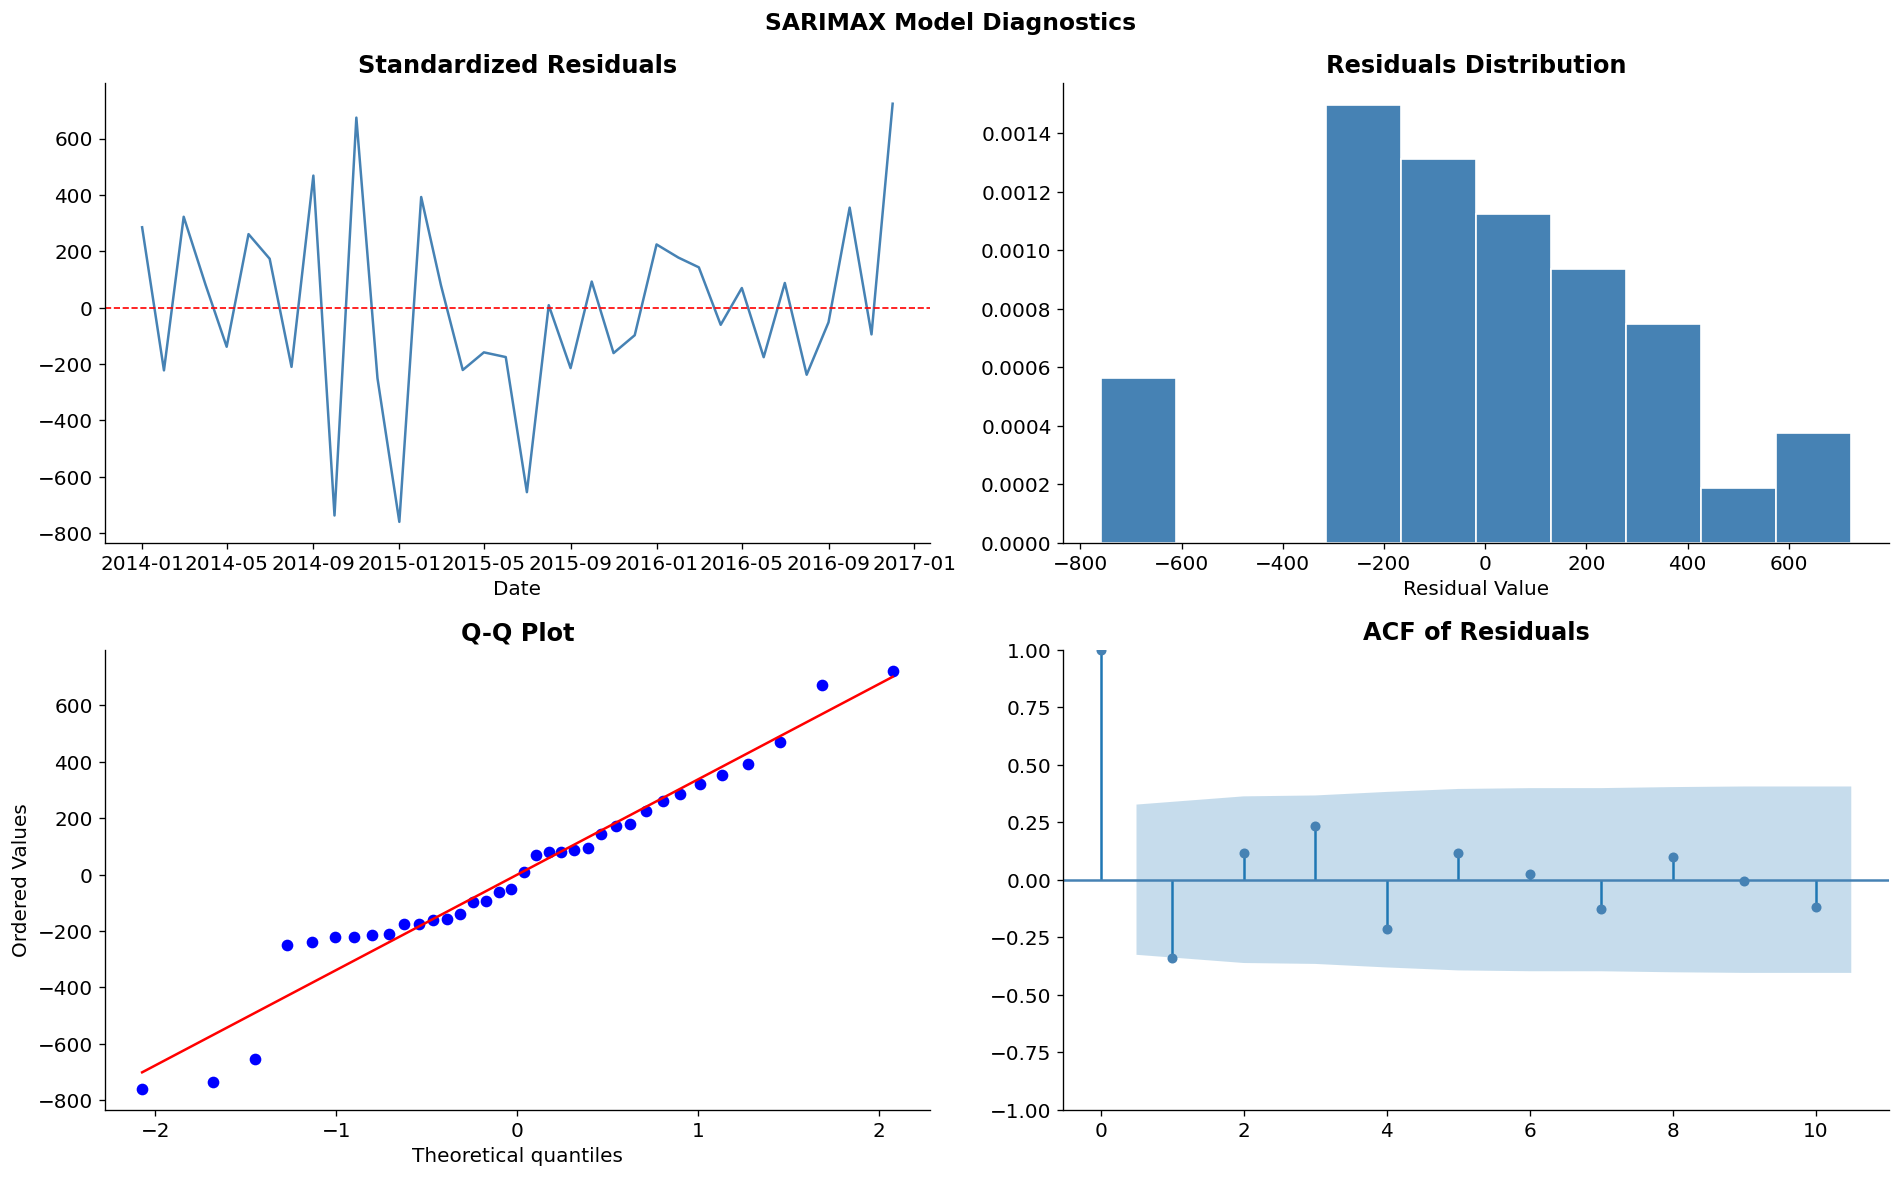

In [29]:
# Thay thế cell SARIMAX diagnostics bằng code này
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

residuals = pd.Series(sarimax_result.resid, index=train.index)

# Plot 1: Residuals over time
axes[0, 0].plot(residuals, color='steelblue', linewidth=1.5)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Standardized Residuals', fontweight='bold')
axes[0, 0].set_xlabel('Date')

# Plot 2: Histogram
axes[0, 1].hist(residuals, bins=10, color='steelblue', edgecolor='white', density=True)
axes[0, 1].set_title('Residuals Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Residual Value')

# Plot 3: Q-Q plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontweight='bold')

# Plot 4: ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=10, ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('ACF of Residuals', fontweight='bold')

plt.suptitle('SARIMAX Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# SARIMAX prediction on test set
sarimax_pred = sarimax_result.forecast(steps=n_test)
sarimax_pred.index = test.index

sarimax_metrics = evaluate_forecast(test, sarimax_pred, 'SARIMAX')


  SARIMAX — Evaluation Metrics
  Metric  Value
MAPE (%) 24.32%
 MAE ($) 199.40
RMSE ($) 282.18


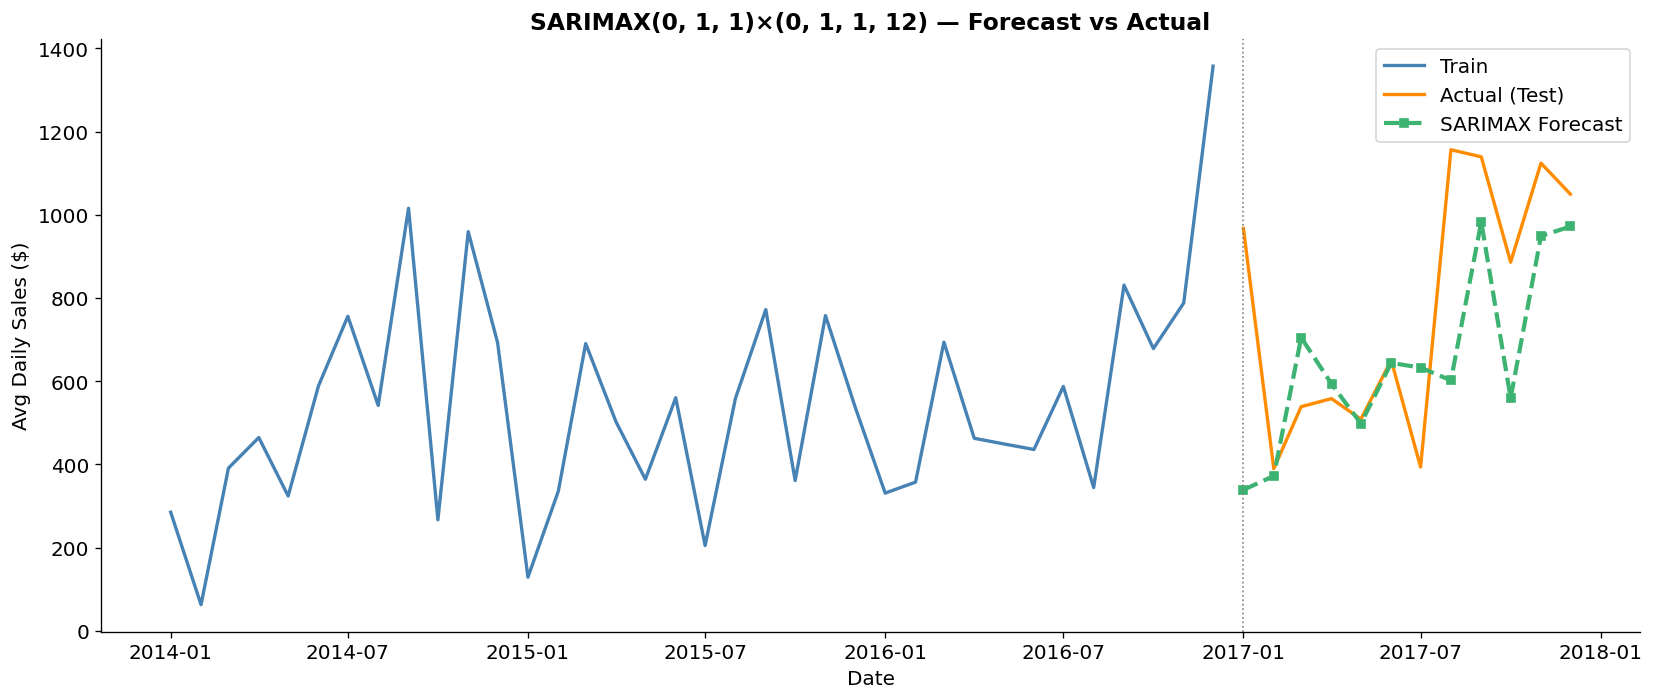

In [31]:
# Plot SARIMAX forecast vs actual
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train, label='Train', color='steelblue', linewidth=2)
ax.plot(test,  label='Actual (Test)', color='darkorange', linewidth=2)
ax.plot(sarimax_pred, label=f'SARIMAX Forecast',
        color='mediumseagreen', linewidth=2.5, linestyle='--', marker='s', markersize=5)
ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1)
ax.set_title(f'SARIMAX{best_order_s}×{best_s_order} — Forecast vs Actual',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Daily Sales ($)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

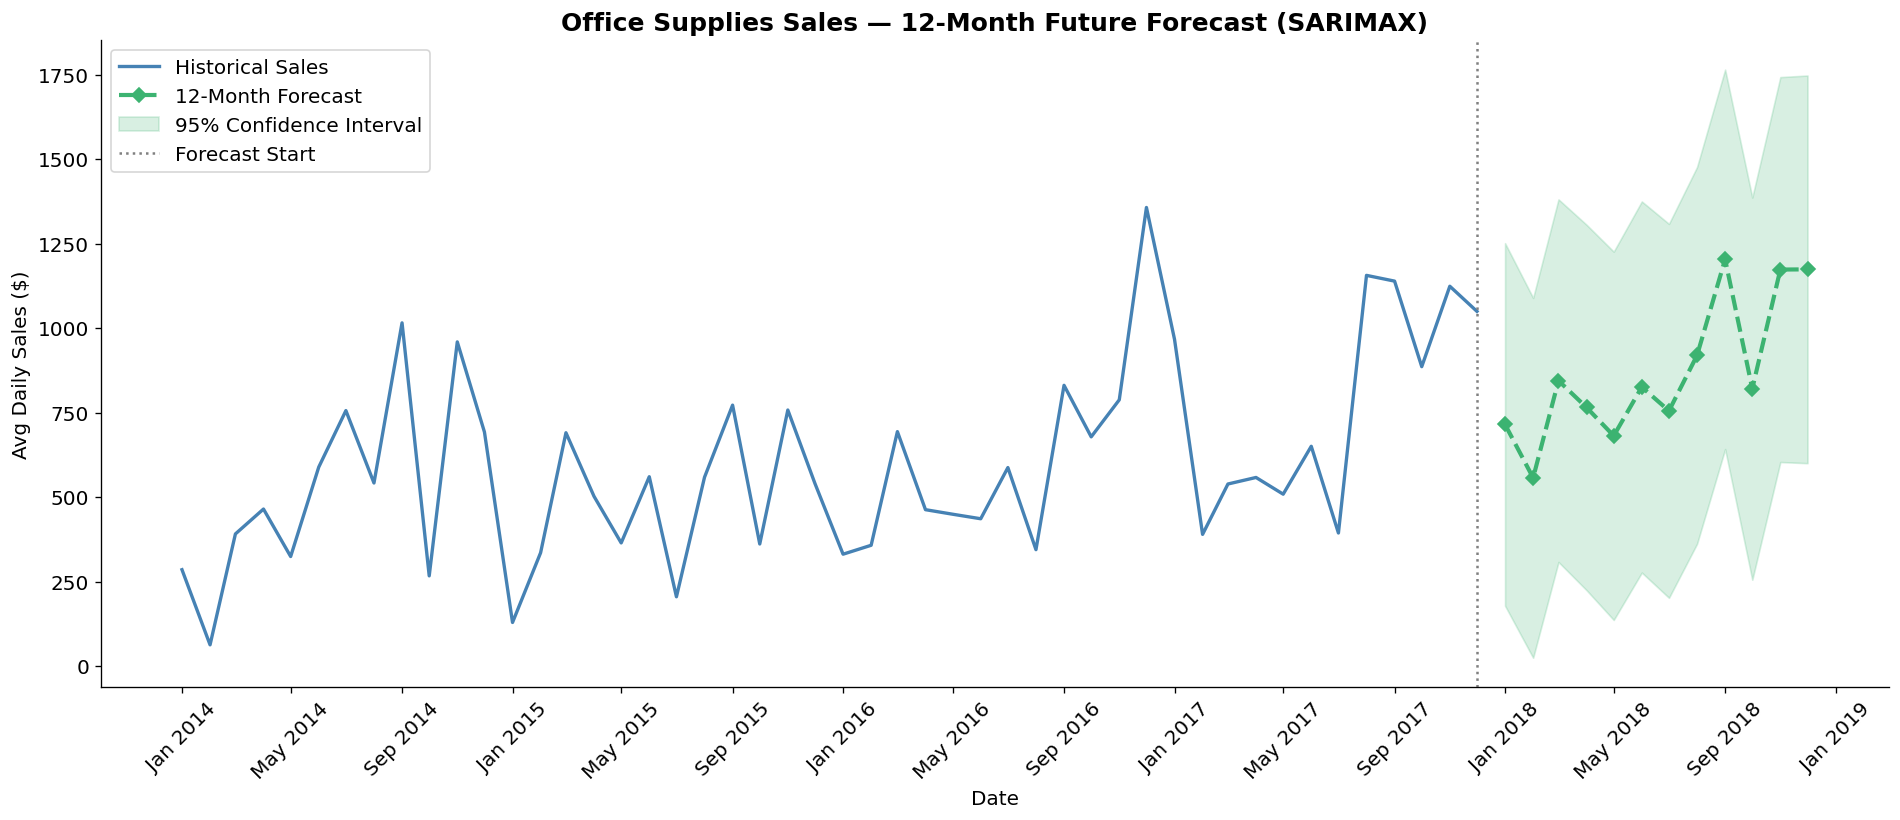


📅 12-Month Forecast Values:
         Month  Forecast ($)  Lower CI ($)  Upper CI ($)
  January 2018        715.04        178.70       1251.39
 February 2018        557.14         24.88       1089.40
    March 2018        844.61        308.21       1381.01
    April 2018        765.29        224.66       1305.93
      May 2018        681.45        136.61       1226.29
     June 2018        825.85        276.83       1374.86
     July 2018        755.33        202.18       1308.49
   August 2018        919.35        362.08       1476.62
September 2018       1203.58        642.23       1764.93
  October 2018        821.00        255.60       1386.41
 November 2018       1173.33        603.91       1742.76
 December 2018       1173.92        600.42       1747.42


In [32]:
# ── 9.3 Forecast Future Sales (12 months ahead) ─────────────────────────────
# Refit on full dataset for best future forecasts
sarimax_full = sm.tsa.statespace.SARIMAX(
    monthly_sales,
    order=best_order_s,
    seasonal_order=best_s_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast 12 months ahead
n_future = 12
future_forecast = sarimax_full.get_forecast(steps=n_future)
future_mean = future_forecast.predicted_mean
future_ci   = future_forecast.conf_int(alpha=0.05)  # 95% confidence interval

# Plot
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(monthly_sales, label='Historical Sales', color='steelblue', linewidth=2)
ax.plot(future_mean,   label='12-Month Forecast', color='mediumseagreen',
        linewidth=2.5, linestyle='--', marker='D', markersize=6)
ax.fill_between(future_ci.index,
                future_ci.iloc[:, 0],
                future_ci.iloc[:, 1],
                color='mediumseagreen', alpha=0.2, label='95% Confidence Interval')
ax.axvline(monthly_sales.index[-1], color='gray', linestyle=':', linewidth=1.5,
           label='Forecast Start')
ax.set_title('Office Supplies Sales — 12-Month Future Forecast (SARIMAX)',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Avg Daily Sales ($)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

print("\n📅 12-Month Forecast Values:")
forecast_table = pd.DataFrame({
    'Month': future_mean.index.strftime('%B %Y'),
    'Forecast ($)': future_mean.values.round(2),
    'Lower CI ($)': future_ci.iloc[:, 0].values.round(2),
    'Upper CI ($)': future_ci.iloc[:, 1].values.round(2)
})
print(forecast_table.to_string(index=False))

In [33]:
# ── Cuối file 04_modeling.ipynb ───────────────────────────────────────────────
import os
os.makedirs('outputs/processed', exist_ok=True)

with open('outputs/processed/models.pkl', 'wb') as f:
    pickle.dump({
        'arima_result':   arima_result,
        'sarimax_result': sarimax_result,
        'sarimax_full':   sarimax_full,
        'train':          train,
        'test':           test,
        'best_order':     best_order,
        'best_order_s':   best_order_s,
        'best_s_order':   best_s_order,
    }, f)

print("✅ Models saved!")

✅ Models saved!


In [34]:
# ── Cuối file 04_modeling.ipynb ───────────────────────────────────────────────
with open('outputs/processed/models.pkl', 'wb') as f:
    pickle.dump({
        'arima_result':   arima_result,
        'sarimax_result': sarimax_result,
        'sarimax_full':   sarimax_full,
        'train':          train,
        'test':           test,
        'best_order':     best_order,
        'best_order_s':   best_order_s,
        'best_s_order':   best_s_order,
        'arima_pred':     arima_pred,    # ← thêm
        'sarimax_pred':   sarimax_pred,  # ← thêm
    }, f)

print("✅ Models saved!")

✅ Models saved!
